In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import matplotlib as mpl

### Preparation

##### Set Labels and Colors for CDR methods, MRV topics, and research methods

In [34]:
cdr_method_colors = {
    
    'SCS': '#a47551', 
    
    'A/R': '#238b45', 
    'General forestry': '#66c2a4', 
    'Agroforestry': '#b2e2e2', 
    'Forest management': '#edf8fb',

    'Biochar': '#ce1256',
    'Restoration of landscapes and peats': '#df65b0',
    'EW': '#d7b5d8', 
  
    'OAE': '#016c59', 
    'OIF/AU': '#1c9099', 
    'DOC': '#67a9cf',
    'Algae ': '#bdc9e1', 
    'Blue carbon': '#f6eff7',
       
    'CCS': '#e31a1c',
    'BECCS': '#fd8d3c', 
    'DACCS': '#fecc5c',
    'CCUS': '#ffffb2', 
    
    'General CDR': '#525252', 
    'Other': '#969696',    
}

# Define the custom color scheme for each CDR group
cdr_group_colors = {
    "SCS": '#C1A28A' ,            # brown for SCS
    "Forestry": '#8fbc8f',         # green for Forestry
    "Terrestrial CDR": '#df65b0',  # green for Terrestrial CDR
 
    "Marine CDR": '#7eaed3',    # bluew for Marine CDR
    "CCS": '#ff7f00',            # orange for CCS
    "General CDR/Other": '#e5e5e5', # grey for General/Other
}  

mrv_topic_colors = {
    'Quantification': '#7da7b8',   # darker bluish-grey
    'Monitoring': '#8dc39f',        # stronger soft green
    'Quality': '#c76a85',           # berry red
    'Governance': '#b39bc8',        # stronger lavender
    'Reporting': '#e1a6b8',         # stronger soft pink
    'Verification': '#a8a8a8',      # medium grey
    'External Impacts': '#d0c97b',   # stronger soft yellow
    'General MRV': '#e5b138',      # muted yellow
    
}

cdr_method_label = \
{
    'SCS': "Soil Carbon Sequestration",
    'A/R': "Afforestation/Reforestation",
    'General forestry': "General Forestry",
    'Agroforestry': "Agroforestry",
    'Forest management': "Forest Management",
    'Biochar': "Biochar",
    'Restoration of landscapes and peats': "Restoration of \nLandscapes/Peats",
    'EW': "Enhanced Weathering",
    'OAE': "Ocean Alkalinity \nEnhancement",
    'OIF/AU': "Ocean Iron Fertilization", 
    'DOC':"Direct Ocean Capture",
    'Algae ':"Algae",
    'Blue carbon': "Blue Carbon Management",
    'CCS':"CCS",
    'BECCS':"BECCS",
    'DACCS':"DACCS",
    'CCUS':"CCUS",
    'General CDR':"General CDR",
    'Other':"Other"
}      

cdr_method_label_v2 = \
{
    'SCS': "Soil carbon sequestration",
    'A/R': "Afforestation/reforestation",
    'General forestry': "General forestry",
    'Agroforestry': "Agroforestry",
    'Forest management': "Forest management",
    'Biochar': "Biochar",
    'Restoration of landscapes and peats': "Restoration of \nlandscapes/peats",
    'EW': "Enhanced weathering \n(land-based)",
    'OAE': "Ocean alkalinity \nenhancement",
    'OIF/AU': "Ocean iron fertilization", 
    'DOC':"Direct ocean \ncapture",
    'Algae ':"Algae",
    'Blue carbon': "Blue carbon \nmanagement",
    'CCS':"CCS",
    'BECCS':"BECCS",
    'DACCS':"DACCS",
    'CCUS':"CCUS",
    'General CDR':"General CDR",
    'Other':"Other"
}     

resMethod_colors = {
     'Modelling':'#e34a33',
     'Data analysis/Statistical analysis/Econometric':'#fdbb84',
     'Remote sensing':'#253494',
     'Experiment - Field study':'#2c7fb8',
     'Experiment - Laboratory experiment':'#41b6c4',
     'Qualitative research':'#31a354'
}

##### Group CDR methods

In [35]:
cdr_group_mapping = {
     # Marine CDR group
    "OIF/AU":"Marine CDR",
    "Blue carbon": "Marine CDR",
    "OAE": "Marine CDR",
    "DOC": "Marine CDR",
    "Algae ": "Marine CDR",
    
    # Terrestrial CDR group
    "EW": "Terrestrial CDR",
    "Biochar": "Terrestrial CDR",
    "Restoration of landscapes and peats": "Terrestrial CDR",
    
    # CCS group
    "DACCS": "CCS",
    "BECCS": "CCS",
    "CCUS": "CCS",
    "CCS": "CCS",
    
    # General CDR/Other group
    "General CDR": "General CDR/Other",
    "Other": "General CDR/Other",

    # SCS
    "SCS": "SCS",

    # Forestry
    "General forestry": "Forestry",
    "A/R": "Forestry",
    "Agroforestry": "Forestry",
    "Forest management": "Forestry",
}

### Get and clean data

In [36]:
df = pd.read_excel("MRVdata_1308.xlsx")
df_filtered = df[df['Year'] != 2024]
df_included = df_filtered[df_filtered['Inclusion/exclusion'] == 'Inclusion'].copy() # new dataframe defined to exclude studies without access or excluded papers

### additonal data

def extract_CDR_method_focus(row):
    CDR_method = []
    CDR_focus = []
    
    for column in cdr_method_colors.keys():  # previously defined list with columns that contain CDR methods
        if row[column] > 0:
            CDR_method.append(column)
            CDR_focus.append(row[column])
    
    return [CDR_method, CDR_focus]
# add new columns to the data frame
df_included['CDR_focus'] = df_included.apply(lambda row: extract_CDR_method_focus(row), axis=1)
df_included['CDR_method'] = df_included.CDR_focus.str[0]
df_included['CDR_focus'] = df_included.CDR_focus.str[1]


#add new column for MRV topic and study focus to the dataset
def extract_MRV_topic_focus(row):
    MRV_topic = []
    MRV_focus = []
    
    for column in mrv_topic_colors.keys():  # previously defined list with columns that contain MRV topics
        if row[column] > 0:
            MRV_topic.append(column)
            MRV_focus.append(row[column])
    
    return [MRV_topic, MRV_focus]
# add new columns to the data frame
df_included['MRV_focus'] = df_included.apply(lambda row: extract_MRV_topic_focus(row), axis=1)
df_included['MRV_topic'] = df_included.MRV_focus.str[0]
df_included['MRV_focus'] = df_included.MRV_focus.str[1]


### explode
# explode CDR method and focus
df_CDRexplode = df_included.explode(['CDR_method', 'CDR_focus'])

# explode MRV topic and focus
df_MRVexplode = df_included.explode(['MRV_topic', 'MRV_focus'])

### create larger groups
# Create a new column ‘CDR_group’ in df_exploded based on the ‘CDR_method’ column
df_CDRexplode['CDR_group'] = df_CDRexplode['CDR_method'].map(cdr_group_mapping)


### Panel B: CDR method - donut

In [37]:
cdr_meth = df_CDRexplode.groupby("CDR_method", as_index=False).size()
cdr_meth["col"] = cdr_meth.CDR_method.replace(cdr_method_colors)
# sorting
cdr_meth.CDR_method = cdr_meth.CDR_method.astype("category")
cdr_meth.CDR_method = cdr_meth.CDR_method.cat.set_categories(cdr_method_colors.keys())
cdr_meth = cdr_meth.sort_values("CDR_method")

df_CDRexplode["CDR_group"] = df_CDRexplode.CDR_method.replace(cdr_group_mapping)
cdr_group = df_CDRexplode.groupby("CDR_group", as_index=False).size()
cdr_group["col"] = cdr_group.CDR_group.replace(cdr_group_colors)
# sorting
cdr_group.CDR_group = cdr_group.CDR_group.astype("category")
cdr_group.CDR_group = cdr_group.CDR_group.cat.set_categories(cdr_group_colors.keys())
cdr_group = cdr_group.sort_values("CDR_group")

Text(-0.3, -0.1, '   184\nstudies')

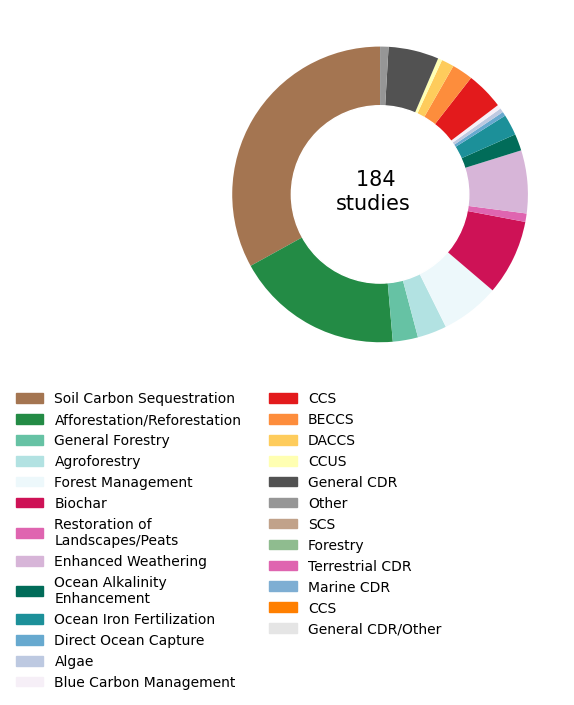

In [38]:
fig, ax = plt.subplots()

ax.pie(cdr_meth["size"], colors=cdr_meth["col"], startangle=90, radius=1)
my_circle = plt.Circle( (0,0), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)

legend_meth = []
for c in cdr_method_colors.keys():
    legend_meth.append(mpatches.Patch(color=cdr_method_colors[c], label=cdr_method_label[c]))
for c in cdr_group_colors.keys():
    legend_meth.append(mpatches.Patch(color=cdr_group_colors[c], label=c))    
leg_meth = plt.legend(handles=legend_meth, bbox_to_anchor=(0.7,0.), fontsize=10, frameon=False,ncol=2)

ax.text(-0.3,-0.1,"   184\nstudies", fontsize=15)

### Panel C: LCA studies

In [39]:
lca = pd.read_excel("MRVdata_2307.xlsx", sheet_name="LCA")
lca_filtered = lca[lca['Year'] != 2024]
lca_included = lca_filtered[lca_filtered['Inclusion/exclusion'] == 'Inclusion'].copy() 

lca_included['CDR_focus'] = lca_included.apply(lambda row: extract_CDR_method_focus(row), axis=1)
lca_included['CDR_method'] = lca_included.CDR_focus.str[0]
lca_included['CDR_focus'] = lca_included.CDR_focus.str[1]

# explode CDR method and focus
lca_CDRexplode = lca_included.explode(['CDR_method', 'CDR_focus'])

In [40]:
lca_cdr_meth = lca_CDRexplode.groupby("CDR_method", as_index=False).size()
lca_cdr_meth["col"] = lca_cdr_meth.CDR_method.replace(cdr_method_colors)
# sorting
lca_cdr_meth.CDR_method = lca_cdr_meth.CDR_method.astype("category")
lca_cdr_meth.CDR_method = lca_cdr_meth.CDR_method.cat.set_categories(cdr_method_colors.keys())
lca_cdr_meth = lca_cdr_meth.sort_values("CDR_method")

lca_CDRexplode["CDR_group"] = lca_CDRexplode.CDR_method.replace(cdr_group_mapping)
lca_cdr_group = lca_CDRexplode.groupby("CDR_group", as_index=False).size()
lca_cdr_group["col"] = lca_cdr_group.CDR_group.replace(cdr_group_colors)
# sorting
lca_cdr_group.CDR_group = lca_cdr_group.CDR_group.astype("category")
lca_cdr_group.CDR_group = lca_cdr_group.CDR_group.cat.set_categories(cdr_group_colors.keys())
lca_cdr_group = lca_cdr_group.sort_values("CDR_group")

Text(-0.3, -0.1, '   114\nstudies')

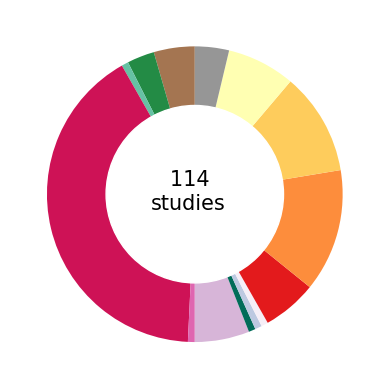

In [41]:
fig, ax = plt.subplots()

ax.pie(lca_cdr_meth["size"], colors=lca_cdr_meth["col"], startangle=90, radius=1)
my_circle = plt.Circle( (0,0), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)

ax.text(-0.3,-0.1,"   114\nstudies", fontsize=15)

### Panel A: Time development

In [42]:
years_df = df_included.groupby("Year", as_index=False).size()
years_df["type"] = "other"
years_lca = lca_included.groupby("Year", as_index=False).size()
years_lca["type"] = "lca"

years = pd.concat([years_df,years_lca])
for y in range(2000,2024):
    for t in ["other","lca"]:
        if len(years[(years.Year==y)&(years.type==t)])==0:
            one_row = pd.DataFrame({"Year":[y],
                        "size":[0],
                        "type":[t]})
            years = pd.concat([years,one_row])
        
years = years.sort_values(["Year"])

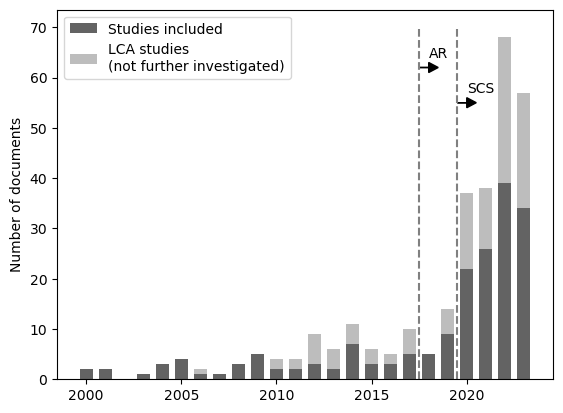

In [43]:
fig, ax = plt.subplots()
type_col = {"lca": '#bdbdbd',
            "other": '#636363'}

type_lab = {
    "other":"Studies included",
    "lca":"LCA studies\n(not further investigated)"
}

width=0.7
prev_values = np.zeros(len(years.loc[years.type=="other","Year"]))
for typ in ["other", "lca"]:
    ax.bar( years.loc[years.type==typ,"Year"],
            years.loc[years.type==typ,"size"], 
            width, bottom=prev_values, 
            label=type_lab[typ],
            color=type_col[typ])
    prev_values += np.array(years.loc[(years.type==typ),"size"])

plt.vlines( [2017.5,2019.5], 0,70, color="grey", ls='--')
    
plt.arrow(2017.5, 62, 1,0, length_includes_head=True, head_width=2, head_length=0.5, color="black")    
plt.arrow(2019.5, 55, 1,0, length_includes_head=True, head_width=2, head_length=0.5, color="black")  
ax.text(2018, 64,"AR")
ax.text(2020, 57,"SCS")
ax.set_ylabel("Number of documents")


ax.legend()

### All together: Final version of Figure 5

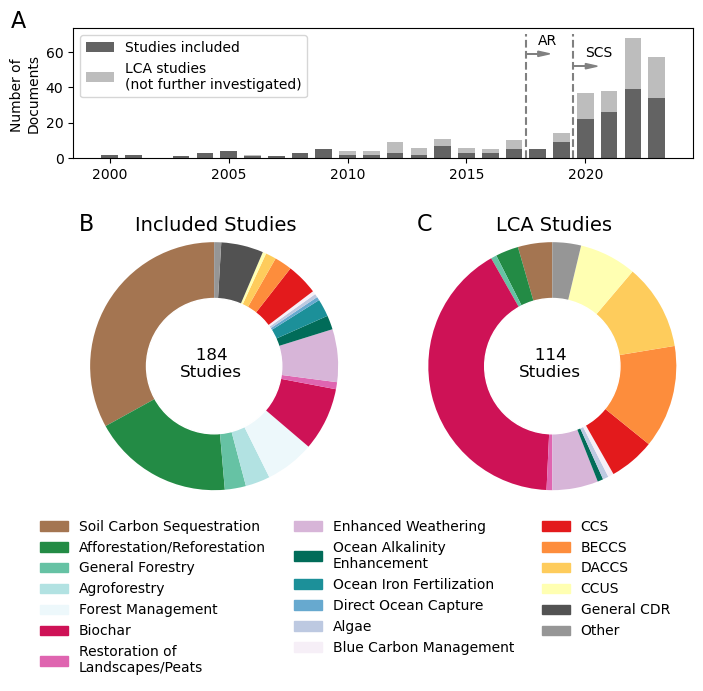

In [44]:
fig = plt.figure(figsize=(8,6.5))
gs = fig.add_gridspec(2,2,height_ratios=[0.4,1],width_ratios=[1,1])

#### time #########################################################
ax1 = fig.add_subplot(gs[0,0:])
prev_values = np.zeros(len(years.loc[years.type=="other","Year"]))
for typ in ["other", "lca"]:
    ax1.bar( years.loc[years.type==typ,"Year"],
            years.loc[years.type==typ,"size"], 
            width, bottom=prev_values, 
            label=type_lab[typ],
            color=type_col[typ])
    prev_values += np.array(years.loc[(years.type==typ),"size"])
    
plt.vlines( [2017.5,2019.5], 0,70, color="grey", ls='--')
plt.arrow(2017.5, 59, 1,0, length_includes_head=True, head_width=3, head_length=0.5, color="grey")    
plt.arrow(2019.5, 52, 1,0, length_includes_head=True, head_width=3, head_length=0.5, color="grey")  
ax1.text(2018, 64,"AR")
ax1.text(2020, 57,"SCS")
ax1.set_ylabel("Number of \nDocuments")
ax1.legend()

##### other studies ################################################
ax2 = fig.add_subplot(gs[1,0])
ax2.pie(cdr_meth["size"], colors=cdr_meth["col"], startangle=90, radius=1.1)
my_circle = plt.Circle( (0,0), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)
ax2.text(-0.3,-0.1,"   184\nStudies", fontsize=12)

###### LCA studies  #################################################
ax3 = fig.add_subplot(gs[1,1])
ax3.pie(lca_cdr_meth["size"], colors=lca_cdr_meth["col"], startangle=90, radius=1.1)
my_circle = plt.Circle( (0,0), 0.6, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)

ax3.text(-0.3,-0.1,"   114\nStudies", fontsize=12)

legend_meth = []
for c in cdr_method_colors.keys():
    legend_meth.append(mpatches.Patch(color=cdr_method_colors[c], label=cdr_method_label[c]))
#for c in cdr_group_colors.keys():
#    legend_meth.append(mpatches.Patch(color=cdr_group_colors[c], label=c))    
leg_meth = plt.legend(handles=legend_meth, loc='upper center', bbox_to_anchor=(-0.2, 0), fontsize=10, frameon=False,ncol=3)

ax2.text(-0.7,1.2,"Included Studies", fontsize=14)
ax3.text(-0.5,1.2,"LCA Studies", fontsize=14)

plt.text(-4.8,3,"A",fontsize=16)
plt.text(-4.2,1.2,"B",fontsize=16)
plt.text(-1.2,1.2,"C",fontsize=16)

fig.savefig('fig5.png', bbox_inches="tight", facecolor='white', edgecolor='none')